In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.arrangements as ar
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations
from Functional_Fusion.util import get_volumes
import SUITPy.flatmap as flatmap
import OptimalBattery.evaluate as ev
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm

In [2]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

# Get group prior (4 parcels trained on mdtb1+mdtb2)

In [3]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [4]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

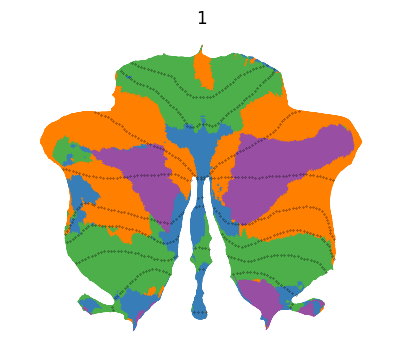

In [5]:
group = full_model.arrange.logpi
group_prob = pt.softmax(group,dim=0)
group_prob = group_prob.reshape(1,-1,group_prob.shape[-1])


group_vol = get_volumes(group_prob.cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(group_vol,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,2),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [6]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

# Load training and testing data

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


# Get Vs and G matrices

In [8]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb_1 = mdtb_1_Vs.detach().numpy()
GL_mdtb_1 = VL_mdtb_1 @ VL_mdtb_1.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

parcel1:Unsure -- parcel2:Motor -- parcel3:socio-linguistic -- parcel4:Multiple demand

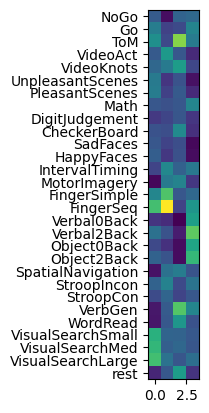

In [9]:
plt.imshow(mdtb_1_Vs)
cond_names = info_mdtb_1_run['cond_name'][:len(VL_mdtb_1)] 
# add condition names from the info file
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

In [10]:
vtest = VL_mdtb_2

In [11]:
data_mdtb_s1_all.shape

(24, 29, 6918)

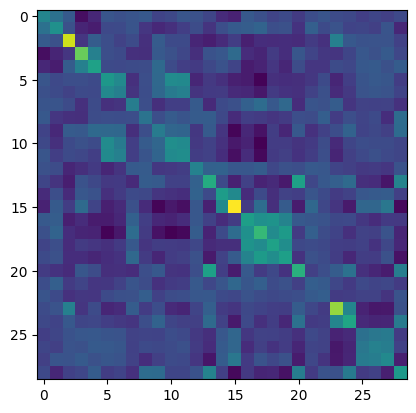

In [12]:
import PcmPy as pcm
import seaborn as sns
import pandas as pd

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

plt.imshow(G_individuals_averaged)

run evaluation on U_hats estimated using HBP framework - data only

In [64]:
D_mdtb = ut.build_combinations(G_individuals_averaged, strategy='balanced',n_iter=10000,n_tasks=5,seed=131,balanced_sampling_unique=[2,3,4,5])
D_mdtb = ev.evaluate_dataframe_real_multiregion(D_mdtb, data_mdtb_s1_all,VL_mdtb_1,data_mdtb_s2_all, vtest)

building0
Processing combination: 0


C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:69: RuntimeWarning: invalid value encountered in divide
  ytest_normalized = ytest / ytest_norm


Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 3400
Processing combination:

In [ ]:
# counts
D_mdtb['n_unique'].value_counts()

In [55]:
n= 220
results_list = []

n_unique_counts = D_mdtb['n_unique'].value_counts()
n_unique_filtered = n_unique_counts[n_unique_counts > n].index.sort_values()

for n_unique_val in n_unique_filtered:
    D_ev_single = D_mdtb[D_mdtb['n_unique'] == n_unique_val]
    D_ev_single = D_ev_single.sample(n=n, random_state=42)


    X = D_ev_single[['variance', 'log_det', 'inverse_trace']]
    y = D_ev_single['cos'].values

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_standardized = (X - X_mean) / X_std

    # Add intercept 
    ones = np.ones(shape=(X_standardized.shape[0], 1))
    X_design = np.hstack([ones, X_standardized])

    # OLS
    Betas = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

    # get the intercept and coefficients
    intercept = Betas[0]
    coefficients = Betas[1:]
    y_pred = X_design @ Betas

    # Calculate R-squared
    residuals = y - y_pred
    SS_res = np.sum(residuals ** 2)
    SS_tot = np.sum((y - y.mean()) ** 2)
    R_squared = 1 - (SS_res / SS_tot)

    result = {
        'n_unique': n_unique_val,
        'intercept': intercept,
        'variance_coef': coefficients[0],
        'log_det_coef': coefficients[1],
        'inverse_trace_coef': coefficients[2],
        'R_squared': R_squared
    }
    results_list.append(result)


results_df = pd.DataFrame(results_list)



<Axes: xlabel='n_unique', ylabel='Value'>

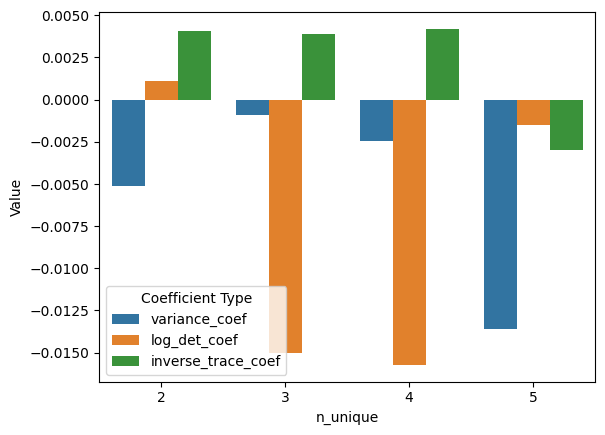

In [56]:
df_melted = results_df.melt(id_vars=["n_unique", "R_squared"], 
                    value_vars=["variance_coef", "log_det_coef", "inverse_trace_coef"], 
                    var_name="Coefficient Type", 
                    value_name="Value")
sns.barplot(data=df_melted, x="n_unique", y="Value", hue="Coefficient Type")



In [ ]:
D_specific = D_mdtb[D_mdtb['n_unique'] == 3]
corr = np.corrcoef(D_specific['cos'], D_specific['variance'])[0, 1]
print(corr)

In [ ]:
# find the battery with the lowest variance
min_idx = D_mdtb['log_det'].idxmin()
max_idx = D_mdtb['log_det'].idxmax()

good_battery = max_idx
bad_battery = min_idx

In [ ]:
min_idx

In [ ]:
bad_battery

In [ ]:
U_individual_volumes = get_volumes(Us[good_battery][:10],atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [ ]:
U_individual_volumes = get_volumes(Us[bad_battery][:10],atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))